# EDA on Processed Banking77 Data

This notebook explores the cleaned and split dataset stored in `processed_data`.

Main topics:
- Dataset size overview
- Missing values and duplicates
- `category` label distribution
- Text length by characters and words
- A few representative text examples


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd()
if not (BASE_DIR / "sample_data").exists() and (BASE_DIR.parent / "sample_data").exists():
    BASE_DIR = BASE_DIR.parent
PROCESSED_DIR = BASE_DIR / "sample_data"

PROC_TRAIN = PROCESSED_DIR / "train.csv"
PROC_VAL = PROCESSED_DIR / "val.csv"
PROC_TEST = PROCESSED_DIR / "test.csv"

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 20)

print("Base dir:", BASE_DIR)
print("Processed dir exists:", PROCESSED_DIR.exists())


Base dir: c:\Users\admin\Desktop\Năm 3\HK2\APPLICATIONS OF NLP IN INDUSTRY\Lab2
Processed dir exists: True


In [6]:
def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    df = pd.read_csv(path)
    return df


proc_train = load_csv(PROC_TRAIN)
proc_val = load_csv(PROC_VAL)
proc_test = load_csv(PROC_TEST)
proc_all = pd.concat([proc_train, proc_val, proc_test], ignore_index=True)

print("Processed train shape:", proc_train.shape)
print("Processed val shape:", proc_val.shape)
print("Processed test shape:", proc_test.shape)
print("Processed combined shape:", proc_all.shape)
proc_all.head()


Processed train shape: (10457, 2)
Processed val shape: (1307, 2)
Processed test shape: (1308, 2)
Processed combined shape: (13072, 2)


,text,category
0,Is my new card activated?,activate_my_card
1,"OMG! I'm trying to load my card and it wont top up! I desperately need the money either on my card or in my bank, ...",pending_top_up
2,Why am I being asked to verify my identity?,why_verify_identity
3,I need quickly transfer something from China. About how long will it take?,transfer_timing
4,Will you guys charge me for topping up by transfer?,top_up_by_bank_transfer_charge


In [7]:
summary = pd.DataFrame({
    "rows": [len(proc_all)],
    "columns": [proc_all.shape[1]],
    "unique_categories": [proc_all["category"].nunique()],
    "missing_text": [proc_all["text"].isna().sum()],
    "missing_category": [proc_all["category"].isna().sum()],
    "duplicate_rows": [proc_all.duplicated(subset=["text", "category"]).sum()],
})

summary


,rows,columns,unique_categories,missing_text,missing_category,duplicate_rows
0,13072,2,77,0,0,0


In [8]:
proc_all["text_len_chars"] = proc_all["text"].astype(str).str.len()
proc_all["text_len_words"] = proc_all["text"].astype(str).str.split().str.len()

length_stats = proc_all[["text_len_chars", "text_len_words"]].describe().T
length_stats


,count,mean,std,min,25%,50%,75%,max
text_len_chars,13072.0,58.244110,39.556340,13.0,36.0,46.0,63.0,433.0
text_len_words,13072.0,11.716187,7.638288,2.0,7.0,10.0,13.0,79.0


Number of classes: 77
Min samples per class: 75
Max samples per class: 227


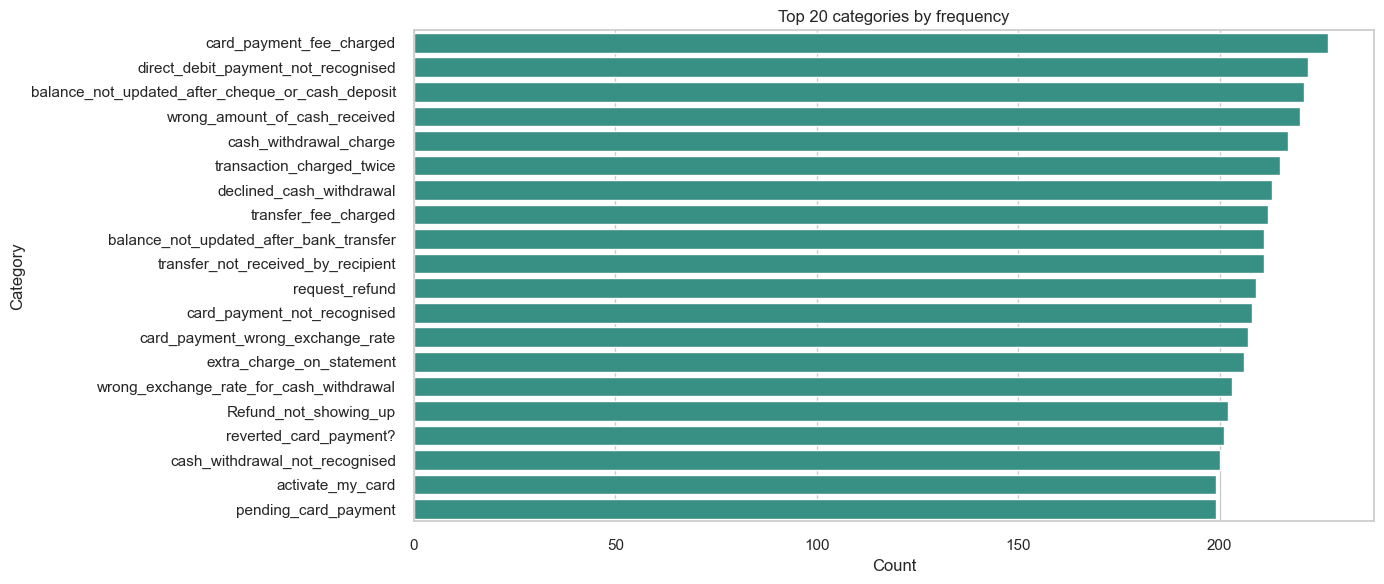

In [9]:
category_counts = proc_all["category"].value_counts()
print("Number of classes:", category_counts.shape[0])
print("Min samples per class:", category_counts.min())
print("Max samples per class:", category_counts.max())

plt.figure(figsize=(14, 6))
top_n = 20
sns.barplot(x=category_counts.head(top_n).values, y=category_counts.head(top_n).index, color="#2a9d8f")
plt.title(f"Top {top_n} categories by frequency")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


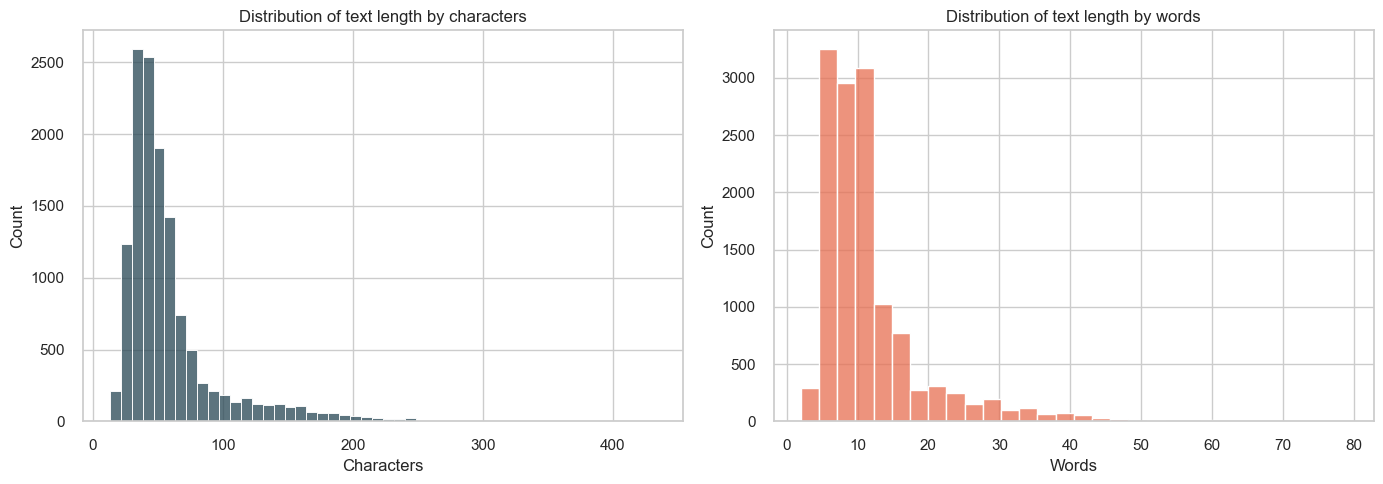

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(proc_all["text_len_chars"], bins=50, ax=axes[0], color="#264653")
axes[0].set_title("Distribution of text length by characters")
axes[0].set_xlabel("Characters")

sns.histplot(proc_all["text_len_words"], bins=30, ax=axes[1], color="#e76f51")
axes[1].set_title("Distribution of text length by words")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()


In [11]:
display_cols = ["text", "category", "text_len_chars", "text_len_words"]
shortest = proc_all.sort_values("text_len_chars").head(10)[display_cols]
longest = proc_all.sort_values("text_len_chars", ascending=False).head(10)[display_cols]

print("Shortest examples")
display(shortest)

print("Longest examples")
display(longest)


Shortest examples


,text,category,text_len_chars,text_len_words
12571,I need my PIN,get_physical_card,13,4
8534,wheres my pin,get_physical_card,13,3
12616,phone is gone,lost_or_stolen_phone,13,3
12445,Lost password,passcode_forgotten,13,2
7387,Fix my top up,top_up_failed,13,4
7409,Can I top up?,top_up_limits,13,4
10900,The card PIN?,get_physical_card,13,3
10417,I lost my card,lost_or_stolen_card,14,4
12258,Change my pin?,change_pin,14,3
7612,My card broke.,card_not_working,14,3


Longest examples


,text,category,text_len_chars,text_len_words
3572,Hearing back from us regarding your important verification results may take 10 minutes to one hour time. If verific...,unable_to_verify_identity,433,79
10117,Hearing about your verification results from us may take anywhere from 10 minutes to approximately one hour. If thi...,unable_to_verify_identity,422,75
10159,Hi! I'm a university student studying abroad and I noticed that when I was trying to cross-reference my budget for t...,transfer_fee_charged,409,78
5911,You will hear back from us about your verification results in 10 minutes to a one hour timeframe. If these verifica...,unable_to_verify_identity,381,70
4948,It can take between 10 minutes to an hour before you hear back from us about the verification result. Please try ag...,unable_to_verify_identity,377,70
10409,"I transferred 7,000 to a receiver outside the EU and they received a lesser amount than what I sent, Unfortunately, ...",transfer_fee_charged,369,68
264,"Hi, Please help me, as i have transferred some amount but receiver did not get the same amount. He received a bit l...",transfer_fee_charged,368,66
1946,"Hi, I would like to file a claim for an inquiry. I am a frequent customer of the company in question and have never ...",reverted_card_payment?,367,69
10247,Hello-Can you please help me get a refund from this merchant? I ordered a product and would like to return it. I ha...,request_refund,364,69
5645,"Transfers may show up as pending for up to one day while they are processed by one of our payment processors. Then, ...",pending_transfer,342,59


In [12]:
samples_per_class = 3
examples = (
    proc_all.sort_values(["category", "text_len_chars"])
    .groupby("category")
    .head(samples_per_class)
    .loc[:, ["category", "text"]]
)

examples.head(30)


,category,text
2169,Refund_not_showing_up,I need my refund
7578,Refund_not_showing_up,My refund is missing
10553,Refund_not_showing_up,I am missing a refund.
7005,activate_my_card,Activate my card
12462,activate_my_card,Activating my card
768,activate_my_card,Card activation steps
7613,age_limit,Is there an age limit?
8387,age_limit,What is the age limit?
3207,age_limit,Is there any age limit?
10707,apple_pay_or_google_pay,is apple pay costly?


In [13]:
split_sizes = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(proc_train), len(proc_val), len(proc_test)],
    "unique_categories": [
        proc_train["category"].nunique(),
        proc_val["category"].nunique(),
        proc_test["category"].nunique(),
    ],
})

display(split_sizes)
print("Missing text:", proc_all["text"].isna().sum())
print("Missing category:", proc_all["category"].isna().sum())
print("Duplicate rows:", proc_all.duplicated(subset=["text", "category"]).sum())
display(proc_all.head())


,split,rows,unique_categories
0,train,10457,77
1,val,1307,77
2,test,1308,77


Missing text: 0
Missing category: 0
Duplicate rows: 0


,text,category,text_len_chars,text_len_words
0,Is my new card activated?,activate_my_card,25,5
1,"OMG! I'm trying to load my card and it wont top up! I desperately need the money either on my card or in my bank, ...",pending_top_up,128,28
2,Why am I being asked to verify my identity?,why_verify_identity,43,9
3,I need quickly transfer something from China. About how long will it take?,transfer_timing,74,13
4,Will you guys charge me for topping up by transfer?,top_up_by_bank_transfer_charge,51,10


## How to read the results

- If the label distribution is highly imbalanced, the model may favor the larger classes.
- If texts are too short or too long, consider additional preprocessing.
- If you see unusual characters, line breaks, or `"` inside the text, recheck the CSV reading and cleaning steps.